<table style="background-color:#FFFFFF">   
  <tr>     
  <td><img src="https://upload.wikimedia.org/wikipedia/commons/9/95/Logo_EPFL_2019.svg" width="150x"/>
  </td>     
  <td>
  <h1> <b>CS-461: Foundation Models and Generative AI</b> </h1>
  Prof. Charlotte Bunne  
  </td>   
  </tr>
</table>

# 📚  Exercise Session - 9

Overview of the coding part:

* [Task 1: Histopathology Foundation Models](#Task-1:-Histopathology-Foundation-Models)
    - [Subtask 1.0: Get familiar with Histopathology images](#Subtask-1.0:-Get-familiar-with-Histopathology-images)
    - [Subtask 1.1: Linear Probing based on FM embeddings](#task-11-linear-probing-based-on-fm-embeddings)
    - [Subtask 1.2: Tissue-level classification](#task-12-tissue-level-classification)
    - [Subtask 1.3: Whole-slide image analysis](#task-13-whole-slide-image-analysis)

<a id="Histopathology"></a>
## Task 1: Histopathology Foundation Models
In this task we are taking a look at one prominent area of Vision Foundation Models trained using DINOv2: Histopathology.
Since there is a bunch of different clincal "downstream" tasks on which one can possibly utilize large FMs, there is a variety of benchmarks available to, e.g., predict tumor (sub-)types, gene expressions within areas of the tissue, interesting Regions of Interest (ROIs). An overview of a few different and commonly used pathology models can be found here: https://birkhoffkiki.github.io/PathBench/. For this exercise, we are using the Phikon2 model.

In [1]:
!pip install torch transformers datasets Pillow umap-learn
!pip install s3fs tiffile imagecodecs zarr scikit-image
!pip install matplotlib seaborn

^C
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached sympy-1.13.1-py3-none-any.whl (6.2 MB)
   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
    --------------------------------------- 0.3/12.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.0 MB 1.4 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/12.0 MB 2.1 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/12.0 MB 1.6 MB/s eta 0:00:07
   ---- ----------------------------------- 1.3/12.0 MB 1.6 MB/s eta 0:00:07
   ----- ---------------------------------- 1

In [2]:
try:
    from umap.umap_ import UMAP
except ImportError:
    from umap import UMAP

c:\Users\theol\anaconda3\envs\SimCLR\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from PIL import Image
import torch
from transformers import AutoImageProcessor, AutoModel
import matplotlib.pyplot as plt
from datasets import load_dataset
from tqdm import tqdm
import numpy as np

In [4]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

<a id="task1.0"></a>
### Task 1.0: Getting familiar with Histopathology images.

**Histopathology background:** <br>
Histopathology is the microscopic examination of tissue samples to study the manifestations of disease. It is widely used in medical diagnosis to identify abnormalities such as cancer, inflammation, and infections. <br>
One of the fundamental staining techniques in histopathology is Hematoxylin and Eosin (H&E) staining. This method uses two dyes: hematoxylin and eosin. Hematoxylin stains cell nuclei a purplish-blue color, highlighting DNA and nuclear structures, while eosin stains the cytoplasm and extracellular matrix various shades of pink or red. The color contrast provided by H&E staining allows pathologists to easily differentiate cellular components and assess tissue architecture and pathological changes effectively. <br>
H&E staining is valued for its simplicity, cost-effectiveness, and ability to provide detailed visualization of tissue structure, making it the gold standard in histopathology laboratories globally. <br>

In the following, we are taking a look at H&E stains of lung tissue samples. More precisly, we are trying to label the lung cancer type of the H&E stains to distinguish between Lung adenocarcinoma (LUAD) and Lung squamous cell carcinoma (LUSC). 

**TODO**: Visualize some of the H&E samples of the dataset and display corresponding the labels and patient ids.

- Are histopathology images different from common images, e.g., as seen in the ImageNet-1k dataset?
- If so, what implications would this have...
    - to data distributions?
    - to general pre-trained FMs for RGB images?
    - to data pre-processing?
    - ...


Visualize some of the crops, print the label as well as as the patient id of the crop.

Possible answers:
- Yes, generally they are brighter than the normal image intensity distribution. If you take a look at histograms of these images, you will see that due to the hematoxylin and eosin staying compared to ImageNet-1k color distribution, you would expect less green colors but more reds and blues in the images.
- The diversity of objects in ImageNet-1k samples is quite high with 1,000 (partially) completely different objects and topics which are shown in the images. In H&E datasets, you will find always very similar images.
- When trying to use traditionally pre-trained FMs (e.g., for ImageNet) with DINOv2, the prototypes of the DINO and iBOT head will focus on distinguishing more general features to be able to self-supervisely separate the embedding space in a meaningful semantic space. These prototypes, however, will the diversity of differnt histopathology slides. Therefore, standard FMs are not suitable to be used directly but should be fine-tuned to the topic-specific image/data distributions. This is a general point to respect when training FMs for Science. (Think about satellite images, etc...)
- Data pre-processing can largely stay the same since we are still dealing with RGB images. However, some pathology FMs use different image normalization values to respect the difference in color distribution.

In [5]:
ds_train = load_dataset("dakomura/tcga-ut", "internal", split="train", streaming=True) # if you get an error here, try setting streaming=False. This will download the dataset locally in advance.
ds_train = ds_train.filter(lambda sample: "Lung" in sample["json"]["label"])

ds_test = load_dataset("dakomura/tcga-ut", "internal", split="test", streaming=True)
ds_test = ds_test.filter(lambda sample: "Lung" in sample["json"]["label"])

c:\Users\theol\anaconda3\envs\SimCLR\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\theol\.cache\huggingface\hub\datasets--dakomura--tcga-ut. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [6]:
# Load phikon-v2
processor = AutoImageProcessor.from_pretrained("owkin/phikon-v2", use_fast=True)
model = AutoModel.from_pretrained("owkin/phikon-v2")
model.eval()
model.to(device)

c:\Users\theol\anaconda3\envs\SimCLR\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\theol\.cache\huggingface\hub\models--owkin--phikon-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP downlo

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-23): 24 x Dinov2Layer(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((1024,),

In [7]:
def load_and_process_image(sample):
    image_bytes = sample["jpg"]
    # image = Image.open(io.BytesIO(image_bytes))
    image = image_bytes
    return {
        "image": image,
        "label": sample["json"]["label"],
        "patient_id": sample["__key__"][:12] # TCGA-XX-XXXX
    }

ds_train_processed = ds_train.map(load_and_process_image, remove_columns=["jpg", "json", "__key__", "__url__"])
ds_test_processed = ds_test.map(load_and_process_image, remove_columns=["jpg", "json", "__key__", "__url__"])

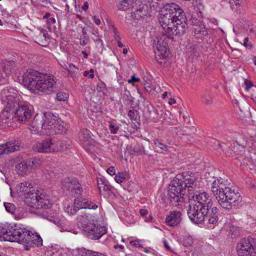

Label: Lung_adenocarcinoma 	 PID: TCGA-55-8614


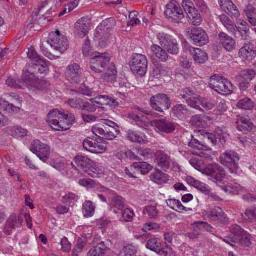

Label: Lung_adenocarcinoma 	 PID: TCGA-55-8614


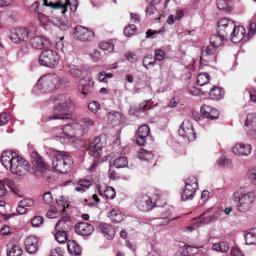

Label: Lung_adenocarcinoma 	 PID: TCGA-71-8520


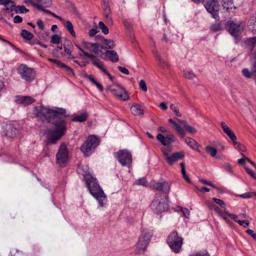

Label: Lung_adenocarcinoma 	 PID: TCGA-86-7955


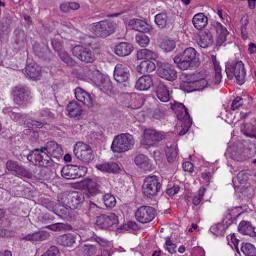

Label: Lung_adenocarcinoma 	 PID: TCGA-55-7903


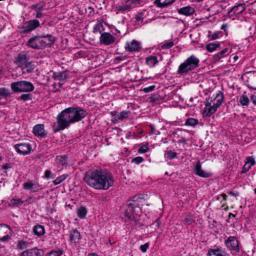

Label: Lung_squamous_cell_carcinoma 	 PID: TCGA-33-4582


In [8]:
iter_ds = iter(ds_train_processed)

### YOUR CODE ###
for i in range(6):
    sample = next(iter_ds)
    display(sample["image"])
    print("Label:", sample["label"], "\t PID:", sample["patient_id"])

<a name="task1.1"></a>
### Task 1.1: Linear Probing based on FM embeddings
**TODO**: 
1. Embed the training crops, store the patient ids as well as the labels. 
2. Visualize the embeddings using a UMAP
3. Fit a Logistic Regression (LR) model on the training set
4. Embed the testset crops, and evaluate the LR using accuracy and F1-score.


In [9]:
ds_train_processed = ds_train_processed.with_format("torch")
ds_test_processed = ds_test_processed.with_format("torch")

BATCH_SIZE = 32
EMBEDDING_SIZE = 1024
NR_BATCHES = 100

dl_train = torch.utils.data.DataLoader(
    ds_train_processed,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
)

In [10]:
embeddings = torch.zeros((BATCH_SIZE * NR_BATCHES, EMBEDDING_SIZE))
labels = []
patient_ids = []

with torch.inference_mode():
    with torch.autocast(device.type, torch.bfloat16):
        for i, batch in enumerate(tqdm(dl_train, total=NR_BATCHES)):
            inputs = processor(batch["image"], return_tensors="pt").to(device)

            ### YOUR CODE ###
            outputs = model(**inputs)
            cls_tokens = outputs.last_hidden_state[:, 0, :].cpu()
            embeddings[BATCH_SIZE * i: BATCH_SIZE * (i+1)] = cls_tokens
            labels += batch["label"]
            patient_ids += batch["patient_id"]
            ### END YOUR CODE ###


            if i == (NR_BATCHES - 1):
              break

 99%|█████████▉| 99/100 [00:15<00:00,  6.33it/s]


Now that we have encoded our lung histopathology crops, visualize them in a UMAP.
Using the same umap embedding, color the plot once by patient ids and once by tumor type.

Create a second UMAP in which you visualize the embedded crops from only four patients, e.g. ['TCGA-33-4582', 'TCGA-55-8614', 'TCGA-77-8138', 'TCGA-71-8520'].

- What do you see in the UMAPs?
    - Are there overlapping classes?
    - If so why, if not why not?
    - How nicely are the cancer types clustering?
    - Do we also see clustering in the patients? Why could this be?

Possible answers:
- We see fairly well balanced class labels, so the underlying dataset seems to be well balanced.
- One can see a clear trend of the two binary classes (on the left UMAP). This already suggests that the crops should be fairly easily predicted with less powerful models (like a logistic regression model). Note that even if a UMAP is not showing a clear separation of classes, this does not imply that the classes are not linearly separable!
- The overlapping further suggests that the FM is understanding certain trends in the crops and resulting in a coherent embedding space for the two cancer type classes.
- When taking a look at the clustering of only a few patients, we even see that these patients are clustering as well, not only w.r.t. the cancer type but also to the originating patient of the tissue. This could be explained through either similar morphology of the crops within one patient but it could also arise from batch effects within our dataset. E.g., one whole-slide tissue from which the crops were sampled from might have been scanned by a different microscope, or different light condition as another WSI. Therefore, it is important to always keep such distribution shifts in mind when designing and training FMs (for Scienes)!

/home/querfurth/.conda/envs/exercise9/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


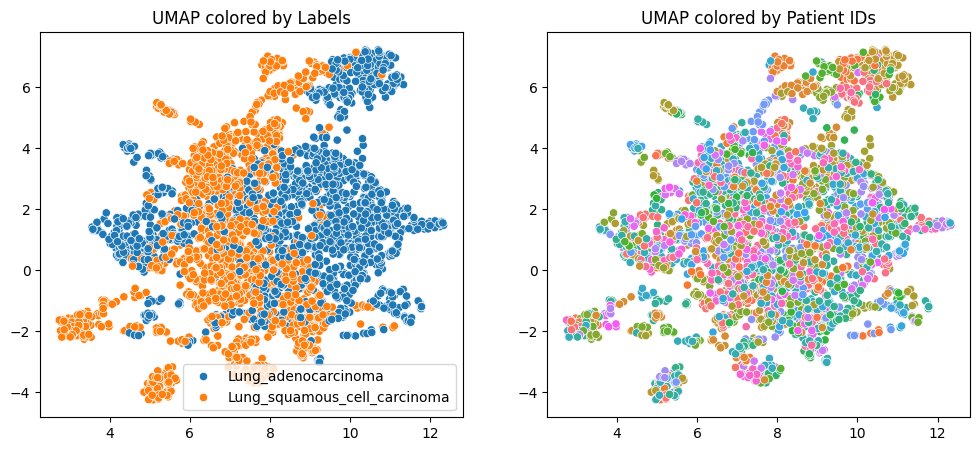

/home/querfurth/.conda/envs/exercise9/lib/python3.9/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


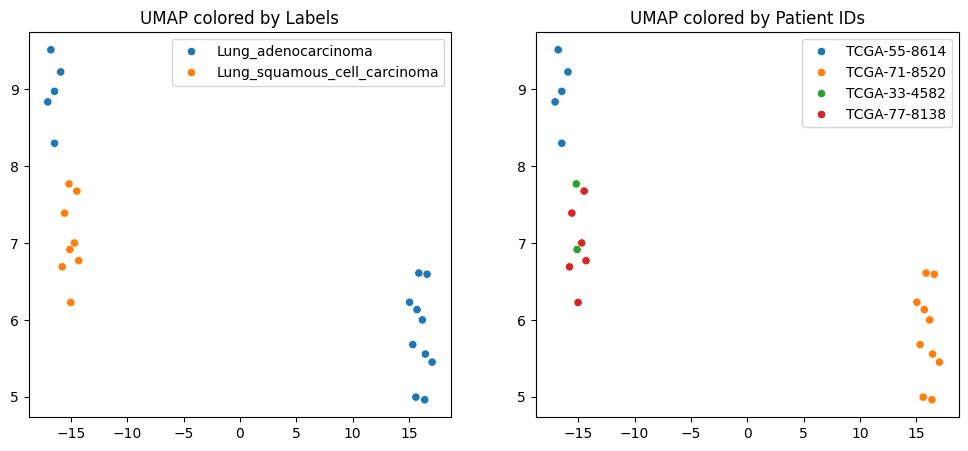

In [11]:
# Apply UMAP
import seaborn as sns
labels = np.array(labels)
patient_ids = np.array(patient_ids)

### YOUR CODE ###
reducer = UMAP(n_neighbors=30, min_dist=0.3, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

fig, axs = plt.subplots(1,2, figsize=(12, 5))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, ax=axs[0])
axs[0].set_title("UMAP colored by Labels")
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=patient_ids, ax=axs[1], legend=False)
axs[1].set_title("UMAP colored by Patient IDs")
plt.show()

# UMAP for selected patient ids
selected_patients = np.array(['TCGA-33-4582', 'TCGA-55-8614', 'TCGA-77-8138', 'TCGA-71-8520'])
patient_ids = np.array(patient_ids)
selected_indices = np.isin(patient_ids, selected_patients)
selected_embeddings = embedding_2d[selected_indices]
selected_labels = labels[selected_indices]
selected_patient_samples = patient_ids[selected_indices]

selected_embedding_2d = reducer.fit_transform(selected_embeddings)
fig, axs = plt.subplots(1,2, figsize=(12, 5))
sns.scatterplot(x=selected_embedding_2d[:, 0], y=selected_embedding_2d[:, 1], hue=selected_labels, ax=axs[0])
axs[0].set_title("UMAP colored by Labels")

sns.scatterplot(x=selected_embedding_2d[:, 0], y=selected_embedding_2d[:, 1], hue=selected_patient_samples, ax=axs[1])
axs[1].set_title("UMAP colored by Patient IDs")
plt.show()

Now, we can do some logistic regression based on the FM embeddings to differentiate between LUAD and LUSC.

First, train a Logistic Regression classifier, afterwards embed the first 100 batches with a batch size of 32 of the test dataset defined above and calculate the accuracy as well as the f1-score on it. Additionally, save the patient ids for the next task.

In [12]:
from sklearn.linear_model import LogisticRegression

### YOUR CODE ###
lr = LogisticRegression()
lr.fit(embeddings, labels)

LogisticRegression()

In [13]:
dl_test = torch.utils.data.DataLoader(
    ds_test_processed,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
)

In [14]:
### YOUR CODE ###
embeddings_test = torch.zeros((BATCH_SIZE * NR_BATCHES, EMBEDDING_SIZE))
labels_test = []
patient_ids_test = []

with torch.inference_mode():
    with torch.autocast(device.type, torch.bfloat16):
        for i, batch in enumerate(tqdm(dl_test, total=NR_BATCHES)):
            inputs = processor(batch["image"], return_tensors="pt").to(device)
            outputs = model(**inputs)
            cls_tokens = outputs.last_hidden_state[:, 0, :].cpu()
            embeddings_test[BATCH_SIZE * i: BATCH_SIZE * (i + 1)] = cls_tokens
            labels_test += batch["label"]
            patient_ids_test += batch["patient_id"]

            if i == (NR_BATCHES - 1):
                break


 99%|█████████▉| 99/100 [00:14<00:00,  6.90it/s]


In [15]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

### YOUR CODE ###
labels_test = np.array(labels_test)
patient_ids_test = np.array(patient_ids_test)

lr_predictions = lr.predict(embeddings_test)
acc_test = accuracy_score(labels_test, lr_predictions)
f1_test = f1_score(labels_test, lr_predictions, average='macro')
print('Test accuracy:', acc_test)
print('Test f1:', f1_test)

Test accuracy: 0.8921875
Test f1: 0.8921402165461011


<a id="task1.2"></a>
### Task 1.2: Tissue-level classification

Until now, we did everything on a crop level (256x256 pixels) extracted from a larger pathology whole slide that often spans more than 10,000 x 10,000 pixels.
As we are interested in a tissue-level and not crop level task, it would make more sense to derive predictions on a patient level.

**TODO**: 
- Implement majority voting as a simple baseline to derive tissue-level prediction from the logisitic regression based test-set predictions

Note: In assignment 2, we are going to look at more sophisticated models to predict labels from a set of embeddings.




In [16]:
import pandas as pd

### YOUR CODE ###
df = pd.DataFrame({"pid": patient_ids_test, "prediction": lr_predictions, "label": labels_test})
df_majority_voting = df.groupby("pid").agg({"prediction":pd.Series.mode, "label":"first"})

predictions_tissue = df_majority_voting["prediction"].values
labels_tissue = df_majority_voting["label"].values

# resolve ties
predictions_tissue = [p[0] if isinstance(p, np.ndarray) else p for p in predictions_tissue]

Now calculate tissue-level accuracies and f1-score.
- Would you expect improving performances? Why?

Possible answer:
- Yes, we would expect an improvement in the performance. Some of the crops might only show healthy regions of the tissue or do not show any usable parts of the tissue based on which the linear probing could perform well. Taking all crops coming from one patient and taking the label which was predict most often, this should remove some of the 'noise' stemming from unsable crops.
- On the other hand, we already achieve a quite high f1-score of 0.892 which limits the performance increase.

Test tissue-level accuracy: 0.9318181818181818
Test tissue-level f1: 0.931720213805391


<Axes: >

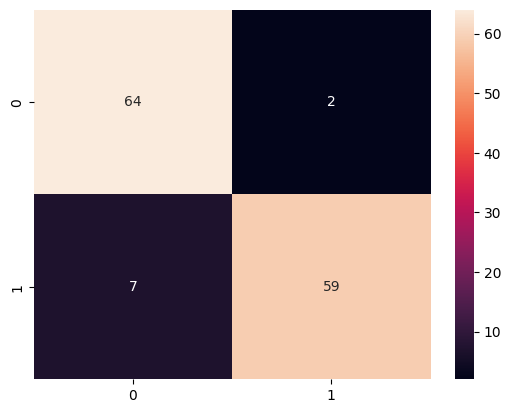

In [17]:
### YOUR CODE ###

acc_tissue_level = accuracy_score(predictions_tissue, labels_tissue)
f1_tissue_level = f1_score(predictions_tissue, labels_tissue, average='macro')
print('Test tissue-level accuracy:', acc_tissue_level)
print('Test tissue-level f1:', f1_tissue_level)

sns.heatmap(confusion_matrix(labels_tissue, predictions_tissue), annot=True)

<a id="task1.3"></a>
### Task 1.3: Whole-slide image analysis

So far we have taken a look at tissue-level downstream tasks where we were interested in global labels. We can also take a look at more local labels in a whole slide image (WSI).

In this task, we are using a WSI originating from a colorectal cancer (CRC) patient. A visualization of the WSI can be found [here](https://www.cycif.org/data/orion-crc/P37_S38-CRC10#s=0#w=0#g=5#m=-1#a=-100_-100#v=0.4618_0.8898_0.6185#o=-100_-100_1_1#p=Q).

**TODO**:
1. Embed the image by using a sliding window
2. Calculate cosine similarities of a protype of the image and all other embeddings
3. Visualize the cosine similarities

In [18]:
import s3fs
import os

fs = s3fs.S3FileSystem(anon=True)
s3_path = 'lin-2023-orion-crc/data/CRC10/18459_LSP10452_US_SCAN_OR_001__091355-registered.ome.tif'

# Local filename to save the image
local_filename = 'crc10_he_wsi.ome.tif'

if not os.path.exists(local_filename):
    # Download the file from S3 to local filesystem
    fs.get(s3_path, local_filename)

print(f'Downloaded {local_filename}')

Downloaded crc10_he_wsi.ome.tif


Loading the image. To save some RAM and compute time, we only take a look at a 10,080 x 10,080 subpart of the WSI.

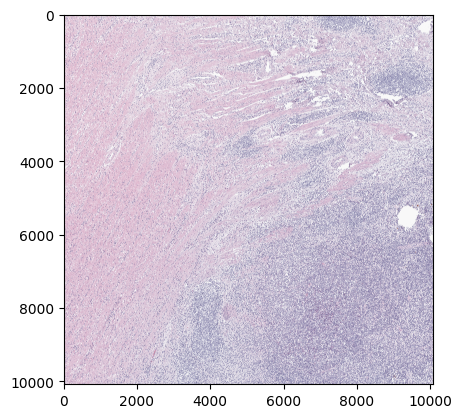

In [19]:
import tifffile

region = tifffile.imread(local_filename)
region = region[15000:25080, 5000:15080]
plt.imshow(region)

Now, embed the tissue by iterating over the image using a crop size of 224x224 without overlap, store the cls tokens and the local patch tokens of each of the crops.

Afterwards, take the top left and the bottom right cls embedding as well as the mean of local patch embeddings of the top left as well as bottom right crop. These will serve as "prototypes". Cacluate the cosine similarities between all cls tokens and the cls-based prototypes and the patches and the patch-based prototypes, respectively.

Hint: the patch size of the Phikon2 model is 16x16.

In [20]:
embeddings_cls = torch.zeros((45,45, EMBEDDING_SIZE))
embeddings_ps = torch.zeros((630,630, EMBEDDING_SIZE))

region_x, region_y = region.shape[:2]

### YOUR CODE ###
with torch.inference_mode():
    with torch.autocast(device.type, torch.bfloat16):
        for x in tqdm(range(0, region_x//224)):
            for y in range(0, region_y//224):
                crop = region[x*224 : (x+1)*224, y*224 : (y+1)*224, :]
                inputs = processor(crop, return_tensors="pt").to(device)
                outputs = model(**inputs)
                cls_tokens = outputs.last_hidden_state[:, 0, :].cpu()
                embeddings_cls[x,y] = cls_tokens
                patch_tokens = outputs.last_hidden_state[:, 1:, :].cpu()
                patch_tokens = patch_tokens.reshape((14,14, EMBEDDING_SIZE))
                embeddings_ps[x*14 : (x+1)*14, y*14 : (y+1) * 14] = patch_tokens

100%|██████████| 45/45 [00:43<00:00,  1.04it/s]


In [21]:
import torch
import torch.nn.functional as F

### YOUR CODE ###
# Top left token
# For the cls tokens first
cls_00 = embeddings_cls[0, 0]  # shape: (EMBEDDING_SIZE,)
cls_00 = cls_00.unsqueeze(0)  # shape: (1, EMBEDDING_SIZE)

vectors_all_cls = embeddings_cls.view(-1, embeddings_cls.shape[2])
cosine_sim_cls_00 = F.cosine_similarity(cls_00, vectors_all_cls, dim=1)
cosine_sim_cls_00 = cosine_sim_cls_00.reshape(embeddings_cls.shape[:2])

# For the cls tokens first
ps_00 = embeddings_ps[0, 0]  # shape: (EMBEDDING_SIZE,)
ps_00 = torch.mean(embeddings_ps[:14, :14], dim=(0,1))
ps_00 = ps_00.unsqueeze(0)  # shape: (1, EMBEDDING_SIZE)

vectors_all_ps = embeddings_ps.view(-1, embeddings_ps.shape[2])
cosine_sim_ps_00 = F.cosine_similarity(ps_00, vectors_all_ps, dim=1)
cosine_sim_ps_00 = cosine_sim_ps_00.reshape(embeddings_ps.shape[:2])

In [22]:
# Bottom right token
# For the cls tokens first
cls_nn = embeddings_cls[-1, -1]  # shape: (EMBEDDING_SIZE,)
cls_nn = cls_nn.unsqueeze(0)  # shape: (1, EMBEDDING_SIZE)

vectors_all_cls = embeddings_cls.view(-1, embeddings_cls.shape[2])
cosine_sim_cls_nn = F.cosine_similarity(cls_nn, vectors_all_cls, dim=1)
cosine_sim_cls_nn = cosine_sim_cls_nn.reshape(embeddings_cls.shape[:2])

# For the cls tokens first
ps_nn = torch.mean(embeddings_cls[-14:, -14:], dim=(0,1)) # shape: (EMBEDDING_SIZE,)
ps_nn = ps_nn.unsqueeze(0)  # shape: (1, EMBEDDING_SIZE)

vectors_all_ps = embeddings_ps.view(-1, embeddings_ps.shape[2])
cosine_sim_ps_nn = F.cosine_similarity(ps_nn, vectors_all_ps, dim=1)
cosine_sim_ps_nn = cosine_sim_ps_nn.reshape(embeddings_ps.shape[:2])

Visualize the cosine similarities on top of the image between the selected prototypes and all other embeddings (once for the cls tokens, once for the patch tokens).

- What do you observe?
- What could this be useful for in a clinical setting?

Potential answers:
- We see that the learnt embedding space of our FM is able to disitinguish more or less fine-granular features from the image. We would not expect a general RGB FM to be able to distinguish them that well.
- These regions can show different interesting environments inside the tissue, for example regions with many immune cells, dense tumor cell areas, or stroma tissue. This can be useful for downstream analysis of the tissue such as understanding the size of a tumor or generally finding similar environments as the one we selected as the prototype.
- The cls tokens show a more high-level representation than the local patch tokens resulting in less noisy but also less detailed heatmaps.

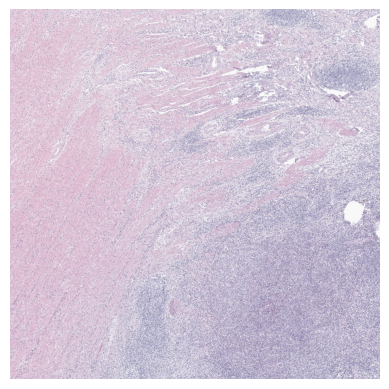

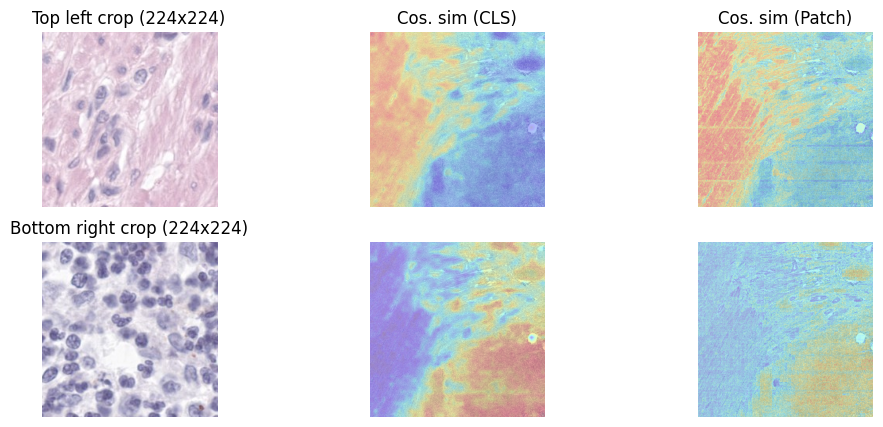

In [23]:
from skimage.transform import resize

### YOUR CODE ###
cosine_sim_cls_00_resized = resize(np.array(cosine_sim_cls_00), (region_x, region_y))
cosine_sim_cls_nn_resized = resize(np.array(cosine_sim_cls_nn), (region_x, region_y))

cosine_sim_ps_00_resized = resize(np.array(cosine_sim_ps_00), (region_x, region_y))
cosine_sim_ps_nn_resized = resize(np.array(cosine_sim_ps_nn), (region_x, region_y))

plt.imshow(region[::10, ::10])
plt.axis('off')
plt.show()

fig, axs = plt.subplots(2,3, figsize=(12, 5))
axs = axs.flatten()
axs[0].imshow(region[:224, :224])
axs[0].set_title("Top left crop (224x224)")
axs[1].imshow(region[::10, ::10])
axs[1].imshow(cosine_sim_cls_00_resized[::10, ::10], alpha=0.3, cmap="jet")
axs[2].imshow(region[::10, ::10])
axs[2].imshow(cosine_sim_ps_00_resized[::10, ::10], alpha=0.3, cmap="jet")
axs[3].imshow(region[-224:, -224:])
axs[3].set_title("Bottom right crop (224x224)")
axs[4].imshow(region[::10, ::10])
axs[4].imshow(cosine_sim_cls_nn_resized[::10, ::10], alpha=0.3, cmap="jet")
axs[5].imshow(region[::10, ::10])
axs[5].imshow(cosine_sim_ps_nn_resized[::10, ::10], alpha=0.3, cmap="jet")

axs[1].set_title("Cos. sim (CLS)")
axs[2].set_title("Cos. sim (Patch)")

for ax in axs:
    ax.axis('off')